In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def parse_mums_file(filepath, label):
    """
    Parses a .mums file.
    - Length: 1st column
    - Present_Count: number of non-empty entries in 2nd column
    - Location_Consistency: 1 if all positions are identical, else 0
    """
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            length = int(parts[0])
            presence_list = [x.strip() for x in parts[1].split(',') if x.strip() != '']
            present_count = len(presence_list)
            is_consistent = 1 if len(set(presence_list)) == 1 else 0
            data.append({
                'Length': length,
                'Present_Count': present_count,
                'Location_Consistency': is_consistent,
                'Dataset': label
            })
    return pd.DataFrame(data)

def calculate_n50(lengths):
    if len(lengths) == 0: return 0
    sorted_lengths = np.sort(lengths)[::-1]
    cumulative_sum = np.cumsum(sorted_lengths)
    return sorted_lengths[np.where(cumulative_sum >= sorted_lengths.sum() / 2)[0][0]]

In [3]:
data_root = "/dodo/rdd4/mft-data/seq-gen-data-cov"

all_data = []
missing = []

for combo in sorted(os.listdir(data_root)):
    combo_path = os.path.join(data_root, combo)
    if not os.path.isdir(combo_path):
        continue
    csv_path = os.path.join(combo_path, 'parsed.csv')
    if os.path.exists(csv_path):
        all_data.append(pd.read_csv(csv_path))
    else:
        missing.append(combo)

if missing:
    print(f"Warning: {len(missing)} folders have no parsed.csv — run preprocess_mums.py first.")
    print("  Missing:", missing[:10], "..." if len(missing) > 10 else "")

df_master = pd.concat(all_data, ignore_index=True)

# Replicate column present for replicated data; default to 1 for legacy folders.
if 'Replicate' not in df_master.columns:
    df_master['Replicate'] = 1

print(df_master.shape)
df_master

(44757334, 7)


,Length,Present_Count,Location_Consistency,Dataset,n,Alpha,Replicate
0,4472,2,1,Nucleotide,100,0.1,1
1,3658,3,1,Nucleotide,100,0.1,1
2,3506,4,1,Nucleotide,100,0.1,1
3,2508,5,1,Nucleotide,100,0.1,1
4,2208,6,1,Nucleotide,100,0.1,1
...,...,...,...,...,...,...,...
44757329,16,25,1,MFT (w=11),75,1.0,9
44757330,10,31,1,MFT (w=11),75,1.0,9
44757331,18,2,0,MFT (w=11),75,1.0,9
44757332,10,3,0,MFT (w=11),75,1.0,9


In [4]:
# Filter to all-present MUMs only (same logic as fig2)
df_filtered = df_master[
    (df_master['Length'] <= 10000) &
    (df_master['Length'] >= 20) &
    (df_master['Present_Count'] == df_master['n']) &
    (df_master['Location_Consistency'] == 1)
]

ns         = sorted(df_master['n'].unique().astype(int))
alphas     = sorted(df_master['Alpha'].unique())
replicates = sorted(df_master['Replicate'].unique().astype(int))
datasets   = ['MFT (w=11)', 'MFT (w=8)', 'MFT (w=5)', 'Nucleotide']

full_index = pd.MultiIndex.from_product(
    [ns, alphas, replicates, datasets],
    names=['n', 'Alpha', 'Replicate', 'Dataset']
)

summary_df = (
    df_filtered
    .groupby(['n', 'Alpha', 'Replicate', 'Dataset'])
    .apply(
        lambda x: pd.Series({
            'N50':                      calculate_n50(x['Length'].values),
            'Total_MUMs':               len(x),
            'Coverage':                 x['Length'].sum(),
            'Location_Consistent_MUMs': x['Location_Consistency'].sum(),
        }),
        include_groups=False,
    )
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(summary_df.shape)
summary_df

(1960, 8)


,n,Alpha,Replicate,Dataset,N50,Total_MUMs,Coverage,Location_Consistent_MUMs
0,5,0.1,1,MFT (w=11),554,30,9664,30
1,5,0.1,1,MFT (w=8),386,42,9584,42
2,5,0.1,1,MFT (w=5),256,66,9535,66
3,5,0.1,1,Nucleotide,197,78,9606,78
4,5,0.1,2,MFT (w=11),394,35,9560,35
...,...,...,...,...,...,...,...,...
1955,200,1.5,9,Nucleotide,0,0,0,0
1956,200,1.5,10,MFT (w=11),0,0,0,0
1957,200,1.5,10,MFT (w=8),0,0,0,0
1958,200,1.5,10,MFT (w=5),0,0,0,0


In [5]:
chain_all     = []
chain_missing = []

for combo in sorted(os.listdir(data_root)):
    combo_path = os.path.join(data_root, combo)
    if not os.path.isdir(combo_path):
        continue
    csv_path = os.path.join(combo_path, 'chained_coverage.csv')
    if os.path.exists(csv_path):
        chain_all.append(pd.read_csv(csv_path))
    else:
        chain_missing.append(combo)

if chain_missing:
    print(f"Warning: {len(chain_missing)} folders missing chained_coverage.csv — run chain_mums.py first.")

chain_df_master = pd.concat(chain_all, ignore_index=True)
print(chain_df_master.shape)
chain_df_master

(41160, 9)


,Dataset,Min_Length,D,Chained_Coverage,Num_Blocks,Mean_Block_Length,n,Alpha,Replicate
0,Nucleotide,10,0,8117,338,24.014793,100,0.1,1
1,Nucleotide,10,50,9979,1,9979.000000,100,0.1,1
2,Nucleotide,10,100,9979,1,9979.000000,100,0.1,1
3,Nucleotide,10,150,9979,1,9979.000000,100,0.1,1
4,Nucleotide,10,200,9979,1,9979.000000,100,0.1,1
...,...,...,...,...,...,...,...,...,...
41155,MFT (w=11),30,100,0,0,0.000000,75,1.0,9
41156,MFT (w=11),30,150,0,0,0.000000,75,1.0,9
41157,MFT (w=11),30,200,0,0,0.000000,75,1.0,9
41158,MFT (w=11),30,500,0,0,0.000000,75,1.0,9


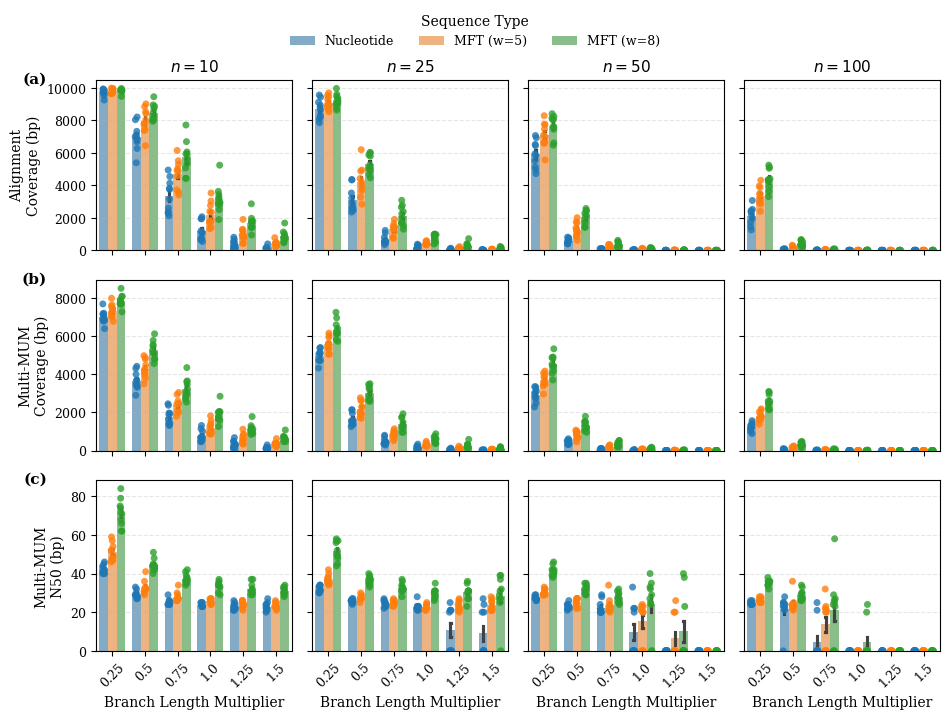

In [20]:
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)']
palette   = "tab10"
# palette = [
#     "#3681b7",  # blue
#     "#FF0000",  # dark green
#     "#ff9d00",  # light green
# ]

# ── Chaining parameters ── change to explore
D_value = 100
l_min   = 20

# ── Subset of n values to show as columns ── change as needed
n_show = [10, 25, 50, 100]

# ── Subset of alpha values to show on x-axis ── set to None to show all
alpha_x_show = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]

# Merge chained coverage at chosen D and l_min into summary_df
chain_at_params = chain_df_master[
    (chain_df_master['D'] == D_value) &
    (chain_df_master['Min_Length'] == l_min)
][['n', 'Alpha', 'Replicate', 'Dataset', 'Chained_Coverage']]

plot_df = summary_df.merge(chain_at_params, on=['n', 'Alpha', 'Replicate', 'Dataset'], how='left')

metrics = [
    ('Chained_Coverage', f'Alignment\nCoverage (bp)', None),
    ('Coverage',         'Multi-MUM\nCoverage (bp)',     None),
    ('N50',              'Multi-MUM\nN50 (bp)',              None),
]
# metrics = [
#     ('Chained_Coverage', f'Alignment\nCoverage (bp)', None),
#     ('Coverage',         'MUM\nCoverage (bp)',     None),
# ]

n_cols = len(n_show)
fig, axes = plt.subplots(len(metrics), n_cols, figsize=(n_cols * 2.4, len(metrics)*2+1), sharey='row', sharex=True)

for col_idx, n_val in enumerate(n_show):
    df_sub = plot_df[plot_df['n'] == n_val]
    if alpha_x_show is not None:
        df_sub = df_sub[df_sub['Alpha'].isin(alpha_x_show)]

    for row_idx, (metric, ylabel, yscale) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.barplot(
            data=df_sub, x='Alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, errorbar='se', alpha=0.6, capsize=0.05,
        )
        sns.stripplot(
            data=df_sub, x='Alpha', y=metric,
            hue='Dataset', hue_order=hue_order,
            ax=ax, palette=palette, legend=False, alpha=0.8, dodge=True,
        )

        if row_idx == 0:
            ax.set_title(f'$n={n_val}$', fontweight='bold')

        ax.set_xlabel(r'Branch Length Multiplier' if row_idx == len(metrics) - 1 else '')
        ax.set_ylabel(ylabel if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if yscale:
            ax.set_yscale(yscale)
        if ax.get_legend():
            ax.get_legend().remove()

for row_idx in range(len(metrics)):
    label = chr(ord('a') + row_idx)
    axes[row_idx, 0].text(-0.25, 1.05, f'({label})', transform=axes[row_idx, 0].transAxes,
                          fontsize=11, fontweight='bold', va='top', ha='right')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('simulated_phylogeny.png', dpi=300, bbox_inches='tight')
plt.savefig('simulated_phylogeny.pdf', dpi=300, bbox_inches='tight')
plt.show()